# Comparación de modelos con y sin augmentation

Comparamos las dos arquitecturas de CNN entrenadas en `cnn_simple.ipynb` / `cnn_profunda.ipynb` contra sus versiones con image augmentation entrenadas en `cnn_augmentation.ipynb` (`augmentation.py`). Los cuatro modelos se evaluaron sobre el mismo split de test (submuestra de 600 imágenes/clase, 64x64):

- **CNN simple**
- **CNN simple + augmentation**
- **CNN profunda**
- **CNN profunda + augmentation**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    "CNN simple": 0.9644,
    "CNN simple + augmentation": 0.9226,
    "CNN profunda": 0.9866,
    "CNN profunda + augmentation": 0.9655,
}

df_comparacion = pd.DataFrame({
    "modelo": list(resultados.keys()),
    "accuracy_test": list(resultados.values()),
})
df_comparacion

,modelo,accuracy_test
0,CNN simple,0.9644
1,CNN simple + augmentation,0.9226
2,CNN profunda,0.9866
3,CNN profunda + augmentation,0.9655


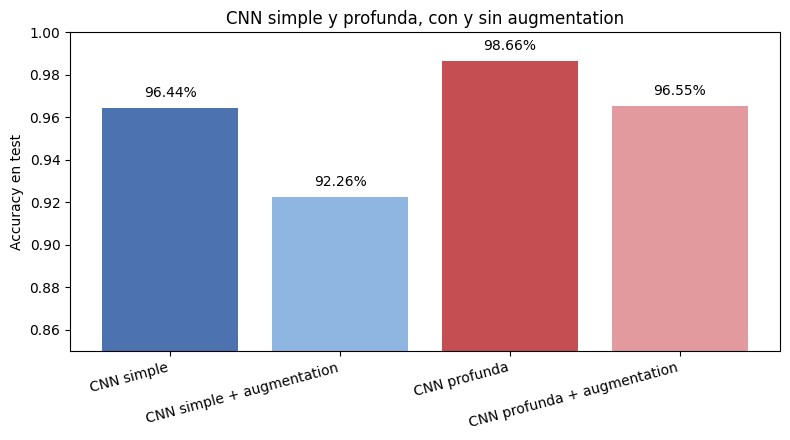

In [2]:
plt.figure(figsize=(8, 4.5))
colores = ["#4C72B0", "#8FB6E0", "#C44E52", "#E29A9E"]
barras = plt.bar(df_comparacion["modelo"], df_comparacion["accuracy_test"], color=colores)

for barra, valor in zip(barras, df_comparacion["accuracy_test"]):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 0.005, f"{valor:.2%}",
             ha="center", fontsize=10)

plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy en test")
plt.title("CNN simple y profunda, con y sin augmentation")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Discusión

**Augmentation bajó el accuracy en test en ambas arquitecturas.** CNN simple pasó de 96.44% a 92.26% (-4.18 puntos) y CNN profunda de 98.66% a 96.55% (-2.11 puntos). En ningún caso la versión con augmentation superó a la original.

**¿Por qué empeora si se supone que ayuda?** El set de test viene de la misma sesión de fotos que el de entrenamiento (mismo fondo, misma iluminación, mismas manos), así que un modelo que memoriza esas condiciones específicas ya tiene ventaja ahí. Rotar, mover, hacer zoom y cambiar brillo/contraste durante el entrenamiento le quita esa ventaja: el modelo ya no puede apoyarse en detalles exactos de posición o iluminación y tiene que aprender la forma de la seña de forma más general. Eso cuesta accuracy en un test tan parecido al train, pero en teoría debería generalizar mejor a fotos tomadas en otras condiciones, como las que se van a usar en el ejercicio 8.

**La brecha entre train y validación cambia de forma consistente con esa idea.** En la última época, CNN simple sin augmentation llega a 91.26% de accuracy en train contra 97.13% en validación, y CNN profunda a 96.53% en train contra 88.54% en validación (antes de que early stopping restaure los mejores pesos), señal de que ambos modelos ya estaban memorizando el set de entrenamiento. Con augmentation, CNN simple queda en 78.82% train contra 92.84% validación, y CNN profunda en 86.14% train contra 95.44% validación. El train accuracy baja porque ahora entrena contra imágenes transformadas, más difíciles, mientras que validación sigue viendo las imágenes originales. Esa brecha más chica y en sentido contrario es la firma típica de que la regularización está funcionando, aunque en este caso el dataset ya era bastante uniforme y no había tanto overfitting que corregir.

**CNN profunda + augmentation sigue siendo mejor que CNN simple + augmentation**, igual que en la comparación sin augmentation, así que el orden entre arquitecturas no cambia. Para este dataset en particular, donde train y test se parecen tanto, los modelos sin augmentation dan mejor número, pero eso no necesariamente los hace mejores para el producto real de SignBridge, donde las fotos van a venir de cámaras, ángulos e iluminación distintos a los del dataset de Kaggle. La elección final entre usar o no augmentation depende de si el objetivo es maximizar accuracy en este test o robustez ante condiciones nuevas.